# Lab 2: Cats vs Dogs Classification Using Transfer Learning


**Course:** Advanced Applied Mathematical Techniques  
**Model:** MobileNetV2  
**Dataset:** Cats vs Dogs  
**Task:** Binary image classification

## Objective
The objective of this project is to use a pretrained MobileNetV2 model and fine-tune it to classify images as either cats or dogs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version: 2.20.0


In [13]:
dataset_url = "https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip"
zip_filename = "cats_and_dogs_filtered.zip"

# Download the zip file using tf.keras.utils.get_file
# get_file will return the full path to the downloaded file in the cache directory
path_to_downloaded_zip = tf.keras.utils.get_file(
    fname=zip_filename,
    origin=dataset_url,
    extract=False # Do not extract automatically
)

# Manually unzip the downloaded file to the /content directory
# The extracted content will be in /content/cats_and_dogs_filtered
!unzip -q -o {path_to_downloaded_zip} -d /content/

# Set the dataset_path to where the data is extracted
dataset_path = "/content/cats_and_dogs_filtered"

print("Dataset path:", dataset_path)


68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset path: /content/cats_and_dogs_filtered


In [16]:
# Verify the contents of the /content directory after extraction
print("Contents of /content/")
!ls -l /content/

print("\nContents of /content/cats_and_dogs_filtered/")
!ls -l /content/cats_and_dogs_filtered/

Contents of /content/
total 8
drwxr-x--- 4 root root 4096 Sep 23  2016 cats_and_dogs_filtered
-rw-r--r-- 1 root root    0 Jul 15 23:36 cats_and_dogs_filtered.zip
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data

Contents of /content/cats_and_dogs_filtered/
total 12
drwxr-x--- 4 root root 4096 Sep 22  2016 train
drwxr-x--- 4 root root 4096 Sep 22  2016 validation
-rw-r----- 1 root root  140 Sep 22  2016 vectorize.py


In [14]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dir = dataset_path + "/train"
validation_dir = dataset_path + "/validation"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


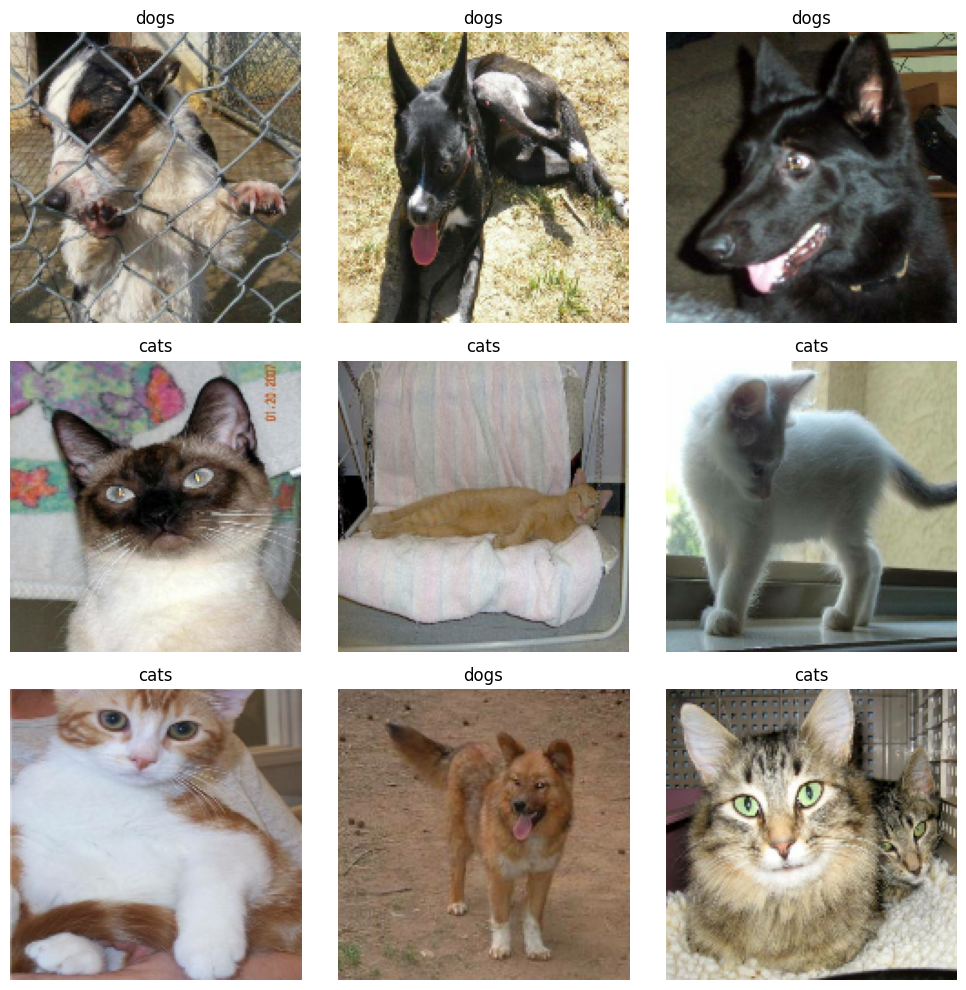

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [18]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
EPOCHS_INITIAL = 5

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INITIAL
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 503ms/step - accuracy: 0.8995 - loss: 0.2492 - val_accuracy: 0.9760 - val_loss: 0.0970
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.9720 - loss: 0.0901 - val_accuracy: 0.9810 - val_loss: 0.0698
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 500ms/step - accuracy: 0.9780 - loss: 0.0635 - val_accuracy: 0.9800 - val_loss: 0.0591
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 484ms/step - accuracy: 0.9810 - loss: 0.0535 - val_accuracy: 0.9830 - val_loss: 0.0515
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 494ms/step - accuracy: 0.9830 - loss: 0.0471 - val_accuracy: 0.9860 - val_loss: 0.0490


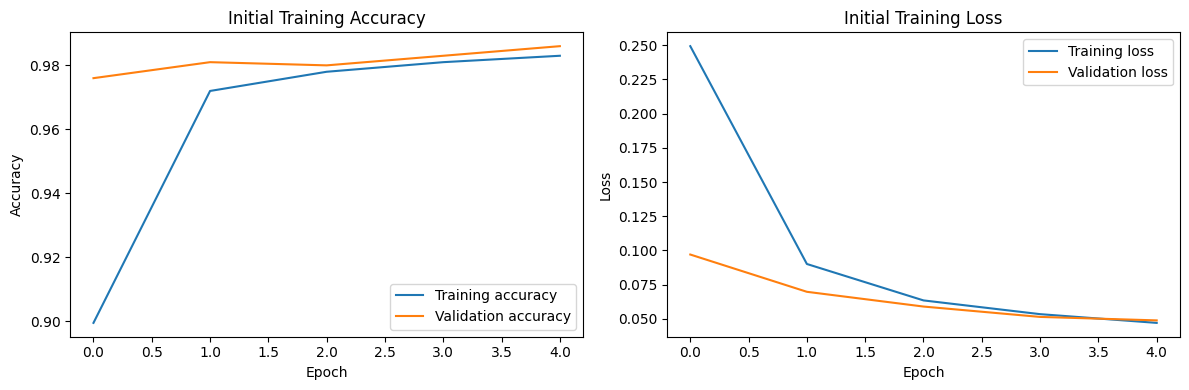

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_initial.history["accuracy"], label="Training accuracy")
plt.plot(history_initial.history["val_accuracy"], label="Validation accuracy")
plt.title("Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_initial.history["loss"], label="Training loss")
plt.plot(history_initial.history["val_loss"], label="Validation loss")
plt.title("Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_FINE_TUNE = 5

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 633ms/step - accuracy: 0.8740 - loss: 0.2891 - val_accuracy: 0.9830 - val_loss: 0.0595
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 629ms/step - accuracy: 0.9535 - loss: 0.1276 - val_accuracy: 0.9780 - val_loss: 0.0678
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 609ms/step - accuracy: 0.9800 - loss: 0.0779 - val_accuracy: 0.9760 - val_loss: 0.0703
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 621ms/step - accuracy: 0.9840 - loss: 0.0619 - val_accuracy: 0.9760 - val_loss: 0.0692
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 627ms/step - accuracy: 0.9915 - loss: 0.0479 - val_accuracy: 0.9790 - val_loss: 0.0649


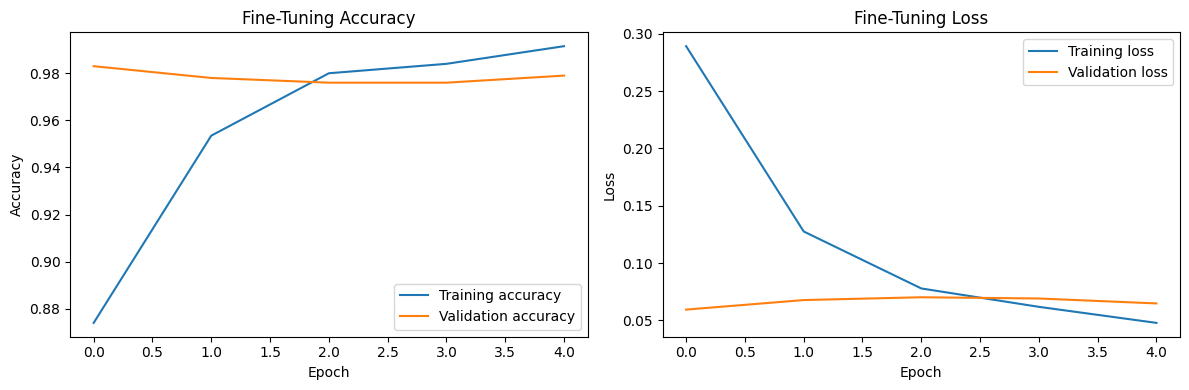

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history["accuracy"], label="Training accuracy")
plt.plot(history_fine_tune.history["val_accuracy"], label="Validation accuracy")
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history["loss"], label="Training loss")
plt.plot(history_fine_tune.history["val_loss"], label="Validation loss")
plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
loss, accuracy = model.evaluate(val_ds, verbose=0)

print(f"Final validation loss: {loss:.4f}")
print(f"Final validation accuracy: {accuracy:.4f}")

Final validation loss: 0.0649
Final validation accuracy: 0.9790


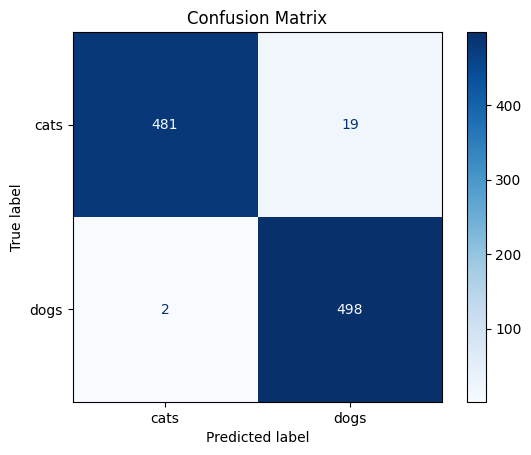

              precision    recall  f1-score   support

        cats       1.00      0.96      0.98       500
        dogs       0.96      1.00      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [24]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

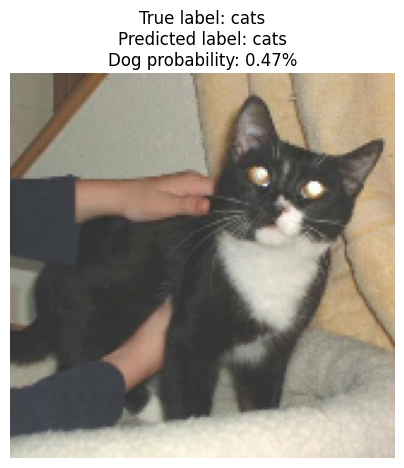

In [25]:
for images, labels in val_ds.take(1):
    image = images[0]
    true_label = class_names[labels[0]]

    prediction = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0][0]
    predicted_label = "dogs" if prediction >= 0.5 else "cats"

    plt.figure(figsize=(5, 5))
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(
        f"True label: {true_label}\n"
        f"Predicted label: {predicted_label}\n"
        f"Dog probability: {prediction:.2%}"
    )
    plt.axis("off")
    plt.show()

In [26]:
model.save("cats_dogs_mobilenetv2.keras")
print("Model saved successfully as cats_dogs_mobilenetv2.keras")

Model saved successfully as cats_dogs_mobilenetv2.keras


## Conclusion

In this project, I used MobileNetV2 pretrained on ImageNet for cat-versus-dog image classification. First, I froze the pretrained layers and trained a new binary classification head. Next, I fine-tuned the last 30 MobileNetV2 layers using a small learning rate.

The model was evaluated using validation accuracy, validation loss, a confusion matrix, and a classification report. Transfer learning made it possible to obtain good results with a relatively small dataset and limited training time.